**Project Title:** Digital media consumption and market trends\
**Author:** Maverick Luke \
**Date:** 11th March, 2025 

# Imports and Constants

In [38]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from datetime import datetime, timedelta
from time import sleep
import yfinance as yf
import praw
import re


In [3]:
# Constants for retrieving data from APIs (not necessary to run the code)
# These constants are used to store the API keys and other sensitive information
with open('tmdb_api_key.txt', 'r') as file:
    for line in file:
        clean_line = line.strip()
        if clean_line:
            API_KEY = clean_line # your api key (can be obtained from https://github.com/rickylawson/freekeys/blob/master/index.js)
            break

with open('reddit_client.txt', 'r') as file:
    lines = file.readlines()
    CLIENT_ID = lines[0].strip() # your client id 
    CLIENT_SECRET = lines[1].strip() # your client secret
    USER_AGENT = lines[2].strip() # python:JSC370.project:v1.0 (by /u/YOUR_REDDIT_USERNAME)

# Introduction

The streaming media landscape has evolved dramatically in recent years, with platforms like Netflix and Disney+ competing intensely for subscribers. Original content has become a primary differentiator in this competition, with platforms investing billions in developing exclusive shows and movies. Meanwhile, social media platforms like Reddit serve as immediate indicators of audience reception, potentially signaling a release's success or failure. This intersection of streaming content strategies and social media engagement raises an important question for investors: How do major content releases on these platforms affect their stock market performance, and can social media metrics serve as leading indicators for these market movements?

## Research Question
This project addresses the question: **How do major streaming content releases on Netflix and Disney+ affect their respective stock prices in the short term, and does social media engagement correlate with these market movements?** \
Specifically, we analyze:

1. Whether stock prices show abnormal returns in the 3-day window following content releases
2. If there are differences in market impact between TV shows and movies
3. Whether Reddit engagement metrics correlate with stock price movements
4. If certain content types or genres generate stronger market reactions than others

# Methods

The study combines data from three distinct sources to examine relationships between streaming content releases, stock market performance, and social media engagement:

- Streaming Content Data: **The Movie Database (TMDB) API** was used to collect information about Netflix and Disney+ releases, including release dates, popularity scores, and genres. Both TV shows and movies were included to ensure a sufficient sample size.
- Stock Market Data: Financial data for Netflix (NFLX), Disney (DIS), and the S&P 500 index was collected using the Yahoo Finance API via the Python **yfinance** package. Daily closing prices, trading volume, and other metrics were gathered for the period from September 2024 to March 2025.
- Social Media Engagement Data: Reddit's API was accessed using the Python **praw** library to collect post and comment data related to each content release. Data was collected from relevant subreddits including r/television, r/netflix, r/DisneyPlus, r/streaming.

## API Implementation
The following code demonstrates how data was collected from each API source:

In [26]:
# Function to get the top releases for a given streaming provider
# The function fetches the top TV shows released on the specified streaming platform
def get_top_releases(provider_id, start_date, end_date, api_key = API_KEY):
    base_url_tv = "https://api.themoviedb.org/3/discover/tv"
    base_url_movie = "https://api.themoviedb.org/3/discover/movie"
    
    tv_results = []
    movie_results = []

    page_tv = 1
    page_movie = 1
    
    while True:
        params_tv = {
            'api_key': api_key,
            'with_watch_providers': provider_id,
            'watch_region': 'US',
            'first_air_date.gte': start_date,
            'first_air_date.lte': end_date,
            'sort_by': 'popularity.desc',
            'page': page_tv
        }
        params_movie = {
            'api_key': api_key,
            'with_watch_providers': provider_id,
            'watch_region': 'US',
            'primary_release_date.gte': start_date,
            'primary_release_date.lte': end_date,
            'sort_by': 'popularity.desc',
            'page': page_movie
        }

        if page_tv < 6: 
            response_tv = requests.get(base_url_tv, params_tv)
            data = response_tv.json()
            if 'results' in data:
                tv_results.extend(data['results'])
            page_tv += 1

        if page_movie < 6:
            response_movie = requests.get(base_url_movie, params_movie)
            data = response_movie.json()
            if 'results' in data:
                movie_results.extend(data['results'])
            page_movie += 1        

        if page_tv >= 6 and page_movie >= 6:
            break

        sleep(0.5)  
    
    for item in tv_results:
        item['provider'] = 'Netflix' if provider_id == 8 else 'Disney+'
        item['provider_id'] = provider_id
        item['content-type'] = 'TV Show'
    
    for item in movie_results:
        item['provider'] = 'Netflix' if provider_id == 8 else 'Disney+'
        item['provider_id'] = provider_id
        item['first_air_date'] = item['release_date']
        item['name'] = item['title']
        item['content-type'] = 'Movie'

    return tv_results, movie_results

def get_all_genre_info():
    genre_tv_url = f"https://api.themoviedb.org/3/genre/tv/list"
    genre_movie_url = f"https://api.themoviedb.org/3/genre/movie/list"
    params = {
        'api_key': API_KEY
    }
    response_tv = requests.get(genre_tv_url, params)
    response_movie = requests.get(genre_movie_url, params)
    
    data_tv = response_tv.json()
    data_movie = response_movie.json()

    return data_tv["genres"], data_movie["genres"]

# Function to get genre information for a given genre ID
# The function returns a list of genre names for the given genre IDs
def get_genre_info(genre_ids, genres_dict):
    genres = []
    for genre_id in genre_ids:
        genre_name = genres_dict.get(genre_id)
        if genre_name:
            genres.append(genre_name)
    return genres


# Get genre information
tv_genres, movie_genres = get_all_genre_info()
tv_genres_dict = {genre['id']: genre['name'] for genre in tv_genres}
movie_genres_dict = {genre['id']: genre['name'] for genre in movie_genres}

# Fetch top releases for Netflix and Disney+ over a 12-month period
start_date = '2024-02-01'
end_date = '2025-02-01'
netflix_releases_tv, netflix_releases_movie = get_top_releases(8, start_date, end_date) # 8 is the ID for Netflix
disney_releases_tv, disney_releases_movie = get_top_releases(337, start_date, end_date) # 337 is the ID for Disney+ 

# Combine the results into a single DataFrame
releases_df_tv = pd.DataFrame(netflix_releases_tv + disney_releases_tv) 
releases_df_movie = pd.DataFrame(netflix_releases_movie + disney_releases_movie)
# Add genre information to the DataFrame
releases_df_tv['genres'] = releases_df_tv['genre_ids'].apply(lambda x: get_genre_info(x, tv_genres_dict))
releases_df_movie['genres'] = releases_df_movie['genre_ids'].apply(lambda x: get_genre_info(x, movie_genres_dict))

releases_df = pd.concat([releases_df_tv, releases_df_movie], ignore_index=True)
releases_df = releases_df[[
    'id', 'name', 'first_air_date', 'popularity', 
    'vote_average', 'vote_count', 'provider', 'provider_id', 'genres', 'content-type'
]]

releases_df['release_date'] = pd.to_datetime(releases_df['first_air_date'])
releases_df['ticker'] = releases_df['provider'].map({
    'Netflix': 'NFLX',
    'Disney+': 'DIS'
})

print(releases_df.shape)
display(releases_df)

(336, 12)


,id,name,first_air_date,popularity,vote_average,vote_count,provider,provider_id,genres,content-type,release_date,ticker
0,207332,SAKAMOTO DAYS,2025-01-11,47.584,8.200,104,Netflix,8,"[Animation, Comedy, Action & Adventure]",TV Show,2025-01-11,NFLX
1,236994,Dragon Ball DAIMA,2024-10-11,10.502,8.132,403,Netflix,8,"[Animation, Action & Adventure, Comedy, Sci-Fi...",TV Show,2024-10-11,NFLX
2,207347,Blue Box,2024-10-03,16.200,8.500,17,Netflix,8,"[Animation, Comedy, Drama]",TV Show,2024-10-03,NFLX
3,275998,Who Saw the Peacock Dance in the Jungle?,2025-01-24,22.481,8.000,2,Netflix,8,"[Drama, Mystery]",TV Show,2025-01-24,NFLX
4,278421,Hell for You,2025-01-14,9.348,5.000,1,Netflix,8,[Drama],TV Show,2025-01-14,NFLX
...,...,...,...,...,...,...,...,...,...,...,...,...
331,1275044,Lainey Wilson: Bell Bottom Country,2024-05-29,0.080,0.000,0,Disney+,337,"[Documentary, Music]",Movie,2024-05-29,DIS
332,1283797,Michael Strahan x Jon Bon Jovi: Halfway There,2024-04-28,0.072,0.000,0,Disney+,337,"[Music, Documentary]",Movie,2024-04-28,DIS
333,1302487,Sins of the Parents: The Crumbley Trials,2024-04-18,0.071,0.000,0,Disney+,337,"[Documentary, Crime]",Movie,2024-04-18,DIS
334,1261524,"An Oprah Special: Shame, Blame and the Weight ...",2024-03-18,0.064,0.000,0,Disney+,337,[Documentary],Movie,2024-03-18,DIS


In [40]:
# Function to get the stock data for the specified tickers and date range
# The function fetches the stock data for the specified tickers from Yahoo Finance
def get_stock_data(tickers, start_date, end_date):
    # Add buffer to start and end dates
    start_buffer = (pd.to_datetime(start_date) - timedelta(days=7)).strftime('%Y-%m-%d')
    end_buffer = (pd.to_datetime(end_date) + timedelta(days=7)).strftime('%Y-%m-%d')
    
    data = yf.download(tickers, start=start_buffer, end=end_buffer, auto_adjust=False)
    
    # Stack the column indices to create a single level of column labels
    df = data.stack(level=1).reset_index()
    df.columns = ['Date', 'Ticker', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

    df = df.sort_values(['Ticker', 'Date'])
    # Calculate daily returns for each stock (in percentage)
    df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change() * 100
    return df

tickers = ['NFLX', 'DIS', '^GSPC']  # Netflix, Disney, and S&P 500
start_date = "2024-02-01"
end_date = "2025-02-01"

stock_data = get_stock_data(tickers, start_date, end_date)
# Replace the ticker symbol for S&P 500 with 'SPY'
stock_data.loc[stock_data['Ticker'] == '^GSPC', 'Ticker'] = 'SPY'
print(stock_data.shape)
print(stock_data.head())

[*********************100%***********************]  3 of 3 completed

(783, 9)
         Date Ticker  Adj Close      Close       High        Low       Open  \
0  2024-01-25    DIS  94.007820  94.860001  94.940002  93.750000  93.919998   
3  2024-01-26    DIS  94.503334  95.360001  95.529999  94.699997  95.000000   
6  2024-01-29    DIS  96.614197  97.489998  97.500000  95.000000  95.419998   
9  2024-01-30    DIS  96.069138  96.940002  97.540001  96.010002  96.519997   
12 2024-01-31    DIS  95.187126  96.050003  97.570000  95.809998  96.419998   

      Volume  Daily_Return  
0    8661600           NaN  
3    7812800      0.527099  
6   13422200      2.233638  
9    9139600     -0.564161  
12   9592300     -0.918101  


In [41]:
# Calculate abnormal returns for each release
def calculate_abnormal_returns(releases, stock_data):
    results = []
    
    for _, release in releases.iterrows():
        ticker = release['ticker']
        release_date = release['release_date']
        
        start_date = release_date
        # Use a 3-day window after the release date to minimize noise
        end_date = release_date + timedelta(days=3)
        
        # Get stock data for this window
        stock_window = stock_data[
            (stock_data['Ticker'] == ticker) & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        # Get market data (S&P 500) for the same window
        market_window = stock_data[
            (stock_data['Ticker'] == 'SPY') & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        if len(stock_window) > 0 and len(market_window) > 0:
            # Calculate cumulative returns
            if len(stock_window) > 1:
                # Use first and last prices
                first_price = stock_window.iloc[0]['Adj Close']
                last_price = stock_window.iloc[-1]['Adj Close']
                stock_return = (last_price - first_price) / first_price * 100
            else:
                stock_return = stock_window.iloc[0]['Daily_Return']
            
            if len(market_window) > 1:
                first_market = market_window.iloc[0]['Adj Close']
                last_market = market_window.iloc[-1]['Adj Close']
                market_return = (last_market - first_market) / first_market * 100
            else:
                market_return = market_window.iloc[0]['Daily_Return']
            
            abnormal_return = stock_return - market_return
            
            result = release.copy()
            result['stock_return'] = stock_return
            result['market_return'] = market_return
            result['abnormal_return'] = abnormal_return
            results.append(result)
    
    return pd.DataFrame(results)

# Change the date to the correct format
releases_df['release_date'] = pd.to_datetime(releases_df['release_date'])
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

returns_df = calculate_abnormal_returns(releases_df, stock_data)
print(f"Number of releases with abnormal returns: {len(returns_df)}")
display(returns_df.sort_values("abnormal_return", ascending=False).head())

Number of releases with abnormal returns: 336


,id,name,first_air_date,popularity,vote_average,vote_count,provider,provider_id,genres,content-type,release_date,ticker,stock_return,market_return,abnormal_return
290,1386628,Marvel Studios Assembled: The Making of Deadpo...,2024-11-12,0.767,6.8,16,Disney+,337,['Documentary'],Movie,2024-11-12,DIS,13.951882,-1.894557,15.846439
138,252551,The Stanford Prison Experiment: Unlocking the ...,2024-11-13,0.217,0.0,0,Disney+,337,['Documentary'],TV Show,2024-11-13,DIS,12.032709,-1.917335,13.950044
310,1232929,Madu,2024-02-07,0.235,7.8,5,Disney+,337,['Documentary'],Movie,2024-02-07,DIS,9.330247,0.631620,8.698627
234,1306764,Outside,2024-10-16,3.691,6.1,129,Netflix,8,"['Horror', 'Thriller']",Movie,2024-10-16,NFLX,8.816241,0.379971,8.436270
299,1235525,Marvel Studios Assembled: The Making of The Ma...,2024-02-06,0.344,5.6,8,Disney+,337,['Documentary'],Movie,2024-02-06,DIS,9.165072,1.460971,7.704100


In [40]:
# Function to retrieve engagement data from Reddit for a given TV show
# The function searches for posts related to the TV show on specific subreddits
# Caution: This function makes multiple requests to the Reddit API and may take some time to run
def get_reddit_engagement(title, release_date, reddit_client):
    if not isinstance(release_date, datetime):
        release_date = pd.to_datetime(release_date)
    
    start_date = release_date - timedelta(days=14)
    end_date = release_date + timedelta(days=14)
    
    search_queries = [
        f'"{title}"',
        f'{title}',
    ] 

    # Remove subtitle from the title (if present)
    clean_title = re.sub(r'[:\-–—].*$', '', title).strip()
    if clean_title != title:
        search_queries.append(f'"{clean_title}"')
    
    subreddits = ['television', 'netflix', 'DisneyPlus', 'streaming']
    
    all_posts = []
    
    for subreddit_name in subreddits:
        subreddit = reddit_client.subreddit(subreddit_name)
        for search_query in search_queries: 
            # Search for posts in the subreddit
            for post in subreddit.search(search_query, sort='relevance', limit=100):
                post_date = datetime.fromtimestamp(post.created_utc)

                if start_date <= post_date <= end_date:
                    all_posts.append({
                        'title': post.title,
                        'subreddit': subreddit_name,
                        'date': post_date,
                        'score': post.score,
                        'num_comments': post.num_comments,
                        'upvote_ratio': post.upvote_ratio,
                        'post_id': post.id
                    })
    
    if len(all_posts) > 0:
        total_posts = len(all_posts)
        total_comments = sum(post['num_comments'] for post in all_posts)
        total_score = sum(post['score'] for post in all_posts)
        avg_upvote_ratio = sum(post['upvote_ratio'] for post in all_posts) / total_posts
    else:
        total_posts = 0
        total_comments = 0
        total_score = 0
        avg_upvote_ratio = 0
    
    return {
        'total_posts': total_posts,
        'total_comments': total_comments,
        'total_score': total_score,
        'avg_upvote_ratio': avg_upvote_ratio
    }


reddit = praw.Reddit(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT
)

engagement_data = []


# releases_df_sample = releases_df.sample(min(30, len(releases_df)), random_state=100)

for index, row in releases_df.iterrows():
    title = row['name']
    release_date = row['release_date']
    engagement = get_reddit_engagement(title, release_date, reddit)
    engagement["name"] = title
    engagement["release_date"] = release_date
    engagement_data.append(engagement)

    sleep(2)
        
engagement_df = pd.DataFrame(engagement_data)
print(engagement_df.head())

   total_posts  total_comments  total_score  avg_upvote_ratio  \
0           14             166          655          0.730714   
1            7             443         6705          0.778571   
2            3               9           25          0.760000   
3            0               0            0          0.000000   
4            4             562         4854          0.587500   

                                       name release_date  
0                             SAKAMOTO DAYS   2025-01-11  
1                         Dragon Ball DAIMA   2024-10-11  
2                                  Blue Box   2024-10-03  
3  Who Saw the Peacock Dance in the Jungle?   2025-01-24  
4                              Hell for You   2025-01-14  


## Content Data Preprocessing
The data structures for TV shows and movies were standardized to ensure consistency. For TV shows, the field first_air_date was renamed to release_date to align with the naming convention used for movies. Additionally, a content_type field was introduced to clearly distinguish between movies and TV shows, making it easier to organize the data. This standardization simplifies comparisons and ensures a unified format across different types of content.

## Stock Data Preprocessing
In the stock data preprocessing phase, two key calculations were performed to analyze stock performance: return calculation and market adjustment. 
First, daily returns were computed as the percentage change in the adjusted closing price from the previous day, providing insight into short-term price movements. 
To isolate company-specific movements from broader market trends, abnormal returns were calculated. This was achieved by subtracting the market return (represented by the S&P 500 index as the benchmark) from the stock return. The formula used was:
abnormal_return = stock_return - market_return.
Finally, event windows were defined to examine the impact of content releases on stock performance. A 3-day post-release window (from the release day to two days after) was specifically analyzed to capture short-term stock reactions to the release of new content.

## Social Media Data Processing
Reddit posts were filtered to a 28-day window (14 days before and after each release) to capture audience engagement around content launches. Key engagement metrics were calculated, including total_posts, total_comments, and total_score (upvotes minus downvotes), to measure how many posts were made, how many comments were shared, and how much people liked the content overall. These metrics provide insights into how actively and positively the audience engaged with the content on social media.

## Data Integration
The processed datasets were merged based on content title and release date. The final integrated dataset included the following key variables:
- Content information: title, release date, platform, popularity, genre, content type
- Stock performance: abnormal returns across different time windows
- Social media engagement: post counts, comment counts, scores

## Tools and Libraries Used
The analysis was conducted using the following Python libraries:

- Data Collection: requests, yfinance, praw
- Data Processing: pandas, numpy
- Time Series Handling: datetime
- Visualization: matplotlib, seaborn

We save each dataset into csv files so that anytime we need the data, we can just read from them.

In [41]:
# Saving the data to a CSV file for convenience
releases_df.to_csv('top_releases.csv', index=False)
stock_data.to_csv('stock_data.csv', index=False)
returns_df.to_csv('abnormal_returns.csv', index=False)
engagement_df.to_csv('reddit_engagement.csv', index=False)

In [19]:
# Read the data from the CSV files (not necessary to run the code if the data is already available)
releases_df = pd.read_csv('top_releases.csv')
stock_data = pd.read_csv('stock_data.csv')
returns_df = pd.read_csv('abnormal_returns.csv')
engagement_df = pd.read_csv('reddit_engagement.csv')

In [9]:
# Exploratory Data Analysis
release_df_summary = releases_df.describe()
stock_data_summary = stock_data.describe()
returns_df_summary = returns_df.describe()  
engagement_df_summary = engagement_df.describe()

print(f"Columns in the datasets:")
print("Releases Data:")
display(release_df_summary)
print("Stock Data:")
display(stock_data_summary)
print("Abnormal Returns Data:")
display(returns_df_summary)
print("Reddit Engagement Data:")
display(engagement_df_summary)



Columns in the datasets:
Releases Data:


,id,popularity,vote_average,vote_count,provider_id
count,3.360000e+02,336.000000,336.000000,336.000000,336.000000
mean,6.799002e+05,3.254655,6.252417,322.940476,141.166667
std,4.740601e+05,4.102799,2.540197,796.690900,161.729151
min,8.245200e+04,0.001000,0.000000,0.000000,8.000000
25%,2.414682e+05,0.672750,6.100000,5.000000,8.000000
50%,5.263585e+05,3.610000,7.000000,82.500000,8.000000
75%,1.181599e+06,3.859500,7.700000,236.500000,337.000000
max,1.442500e+06,47.584000,10.000000,6871.000000,337.000000


Stock Data:


,Adj Close,Close,High,Low,Open,Volume,Daily_Return
count,783.000000,783.000000,783.000000,783.000000,783.000000,7.830000e+02,780.000000
mean,2110.840678,2111.041199,2121.932656,2098.910319,2110.743622,1.330336e+09,0.134300
std,2436.024229,2435.858875,2445.244021,2425.072547,2435.885197,1.923029e+09,1.473354
min,85.222374,85.599998,86.250000,83.910004,85.150002,1.354200e+06,-9.513179
25%,111.603321,112.364998,113.185001,111.120003,111.939999,3.693350e+06,-0.576962
50%,674.070007,674.070007,682.710022,665.109985,673.440002,9.028600e+06,0.092269
75%,5205.074951,5205.074951,5227.469971,5182.229980,5205.354980,3.548540e+09,0.817651
max,6118.709961,6118.709961,6128.180176,6088.740234,6121.430176,8.223220e+09,11.498896


Abnormal Returns Data:


,id,popularity,vote_average,vote_count,provider_id,stock_return,market_return,abnormal_return
count,3.360000e+02,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,6.799002e+05,3.254655,6.252417,322.940476,141.166667,0.243481,0.183976,0.059505
std,4.740601e+05,4.102799,2.540197,796.690900,161.729151,2.319579,0.985475,2.145348
min,8.245200e+04,0.001000,0.000000,0.000000,8.000000,-10.117897,-3.182365,-9.647522
25%,2.414682e+05,0.672750,6.100000,5.000000,8.000000,-0.838511,-0.313643,-0.957797
50%,5.263585e+05,3.610000,7.000000,82.500000,8.000000,0.004626,0.249866,-0.133526
75%,1.181599e+06,3.859500,7.700000,236.500000,337.000000,1.192726,0.875517,0.924810
max,1.442500e+06,47.584000,10.000000,6871.000000,337.000000,13.951882,3.679563,15.846439


Reddit Engagement Data:


,total_posts,total_comments,total_score,avg_upvote_ratio
count,336.000000,336.000000,336.000000,336.000000
mean,2.443452,228.446429,476.821429,0.303084
std,6.737493,911.207130,2029.626691,0.374616
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,2.000000,39.250000,49.000000,0.715592
max,77.000000,10822.000000,23628.000000,1.000000


In [10]:
print("Number of null values in releases_df:", releases_df.isnull().sum().sum())
print("Number of null values in stock_data:", stock_data.isnull().sum().sum())
print("Number of null values in returns_df:", returns_df.isnull().sum().sum())
print("Number of null values in engagement_df:", engagement_df.isnull().sum().sum())


Number of null values in releases_df: 0
Number of null values in stock_data: 3
Number of null values in returns_df: 0
Number of null values in engagement_df: 0


In [20]:
# Display the null values in the datasets
print("Null values in the datasets:")
display(stock_data[stock_data.isnull().any(axis=1)]) 

# Remove the rows with null values in the stock data
clean_stock_data = stock_data.dropna()

Null values in the datasets:


,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Daily_Return
0,2024-01-25,DIS,94.007820,94.860001,94.940002,93.750000,93.919998,8661600,NaN
261,2024-01-25,NFLX,562.000000,562.000000,563.460022,548.460022,551.950012,9451900,NaN
522,2024-01-25,SPY,4894.160156,4894.160156,4898.149902,4869.339844,4886.660156,4020430000,NaN


Daily return calculations require both the current and previous day's adjusted close values. Each of our 3 tickers has one row where the previous day's data is unavailable, resulting in a null value for the daily return on that specific row. This is an expected consequence of our finite dataset rather than an error in the data.

In [42]:
# Merge returns_df and engagement_df on the 'title' and 'release_date' columns
merged_data = pd.merge(returns_df, engagement_df, on=['name', 'release_date'], how='inner')
# Select only the relevant columns
merged_data = merged_data.drop(columns=['id', 'first_air_date', 'provider_id'])
display(merged_data.head())

,name,popularity,vote_average,vote_count,provider,genres,content-type,release_date,ticker,stock_return,market_return,abnormal_return,total_posts,total_comments,total_score,avg_upvote_ratio
0,SAKAMOTO DAYS,47.584,8.200,104,Netflix,"['Animation', 'Comedy', 'Action & Adventure']",TV Show,2025-01-11,NFLX,-1.414982,0.114628,-1.529610,14,166,655,0.730714
1,Dragon Ball DAIMA,10.502,8.132,403,Netflix,"['Animation', 'Action & Adventure', 'Comedy', ...",TV Show,2024-10-11,NFLX,-1.354471,0.770767,-2.125237,7,443,6705,0.778571
2,Blue Box,16.200,8.500,17,Netflix,"['Animation', 'Comedy', 'Drama']",TV Show,2024-10-03,NFLX,1.825131,0.897025,0.928106,3,9,25,0.760000
3,Who Saw the Peacock Dance in the Jungle?,22.481,8.000,2,Netflix,"['Drama', 'Mystery']",TV Show,2025-01-24,NFLX,-0.583068,-1.458072,0.875004,0,0,0,0.000000
4,Hell for You,9.348,5.000,1,Netflix,['Drama'],TV Show,2025-01-14,NFLX,3.585219,2.631394,0.953824,4,562,4854,0.587500


Summary Statistics for the Merged Dataset:


,popularity,vote_average,vote_count,stock_return,market_return,abnormal_return,total_posts,total_comments,total_score,avg_upvote_ratio
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,3.254655,6.252417,322.940476,0.243481,0.183976,0.059505,7.363095,702.139881,1977.812500,0.434504
std,4.102799,2.540197,796.690900,2.319579,0.985475,2.145348,15.932479,2083.705384,6863.175132,0.362039
min,0.001000,0.000000,0.000000,-10.117897,-3.182365,-9.647522,0.000000,0.000000,0.000000,0.000000
25%,0.672750,6.100000,5.000000,-0.838511,-0.313643,-0.957797,0.000000,0.000000,0.000000,0.000000
50%,3.610000,7.000000,82.500000,0.004626,0.249866,-0.133526,2.000000,22.500000,12.500000,0.574545
75%,3.859500,7.700000,236.500000,1.192726,0.875517,0.924810,8.000000,359.500000,529.250000,0.758333
max,47.584000,10.000000,6871.000000,13.951882,3.679563,15.846439,176.000000,22197.000000,59363.000000,1.000000


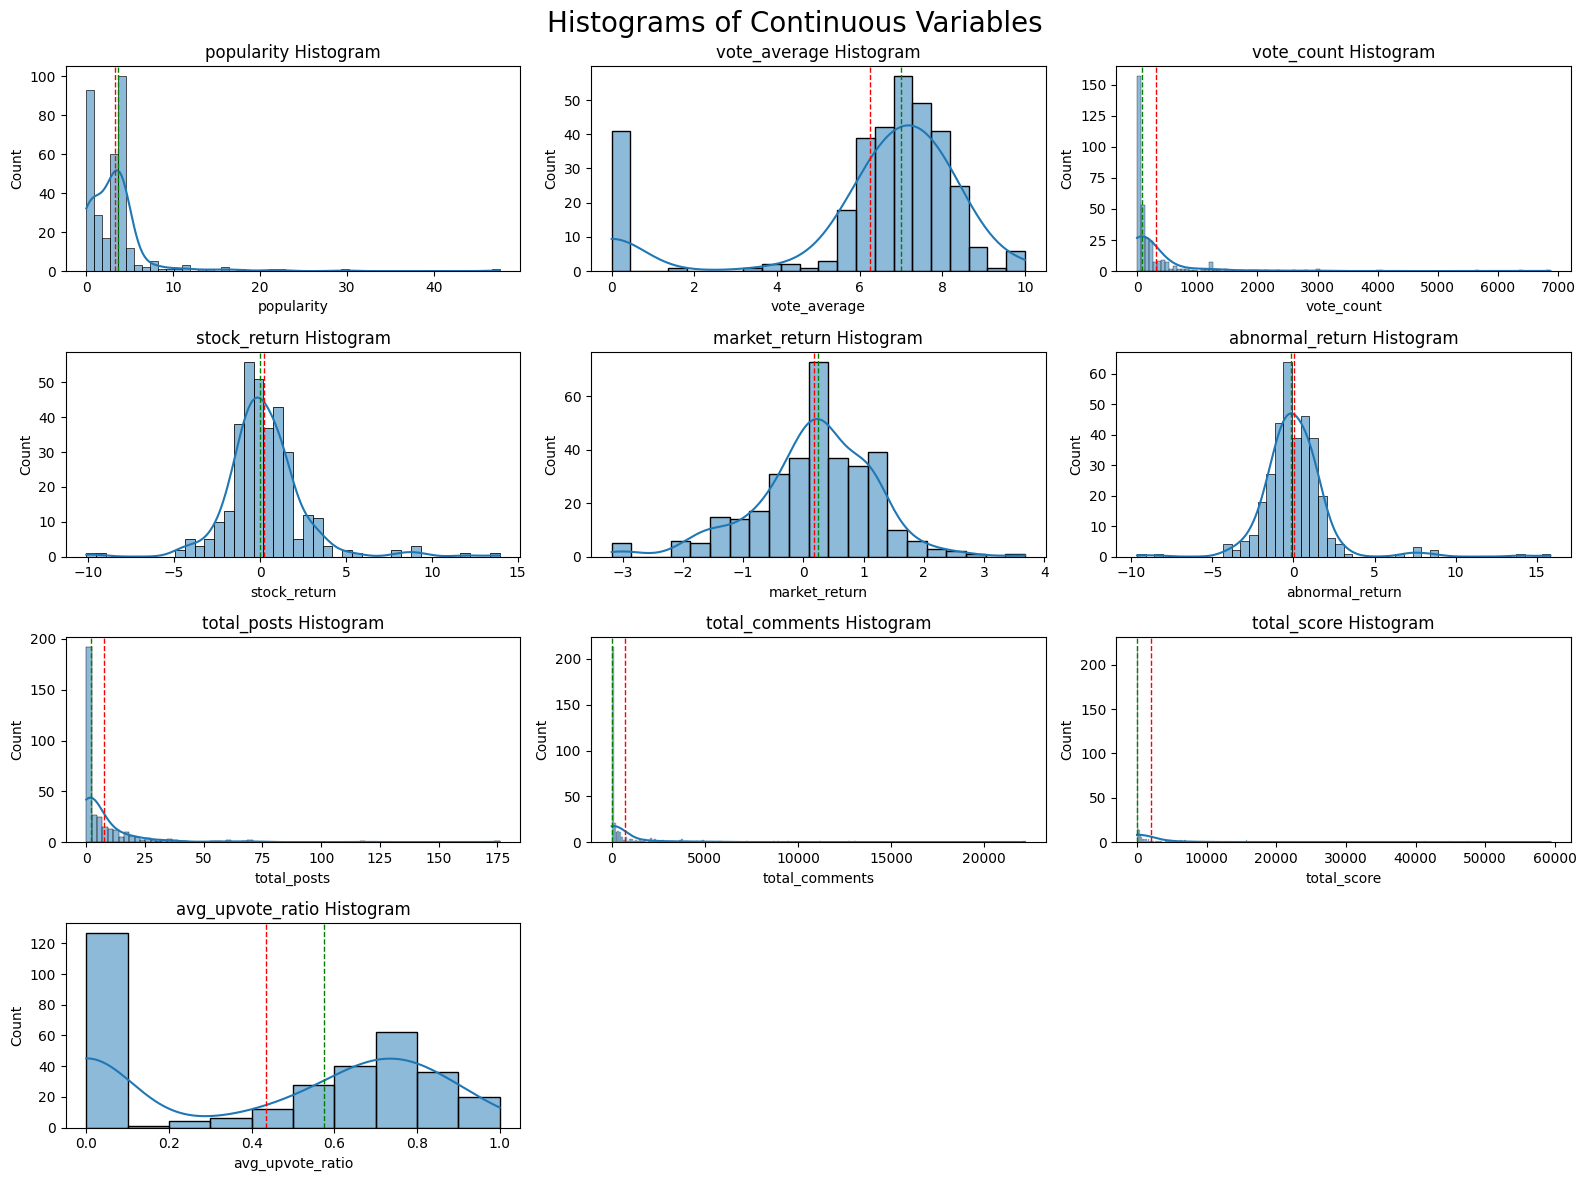

C:\Users\Asus ROG\AppData\Local\Temp\ipykernel_38428\165724958.py:30: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(merged_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")


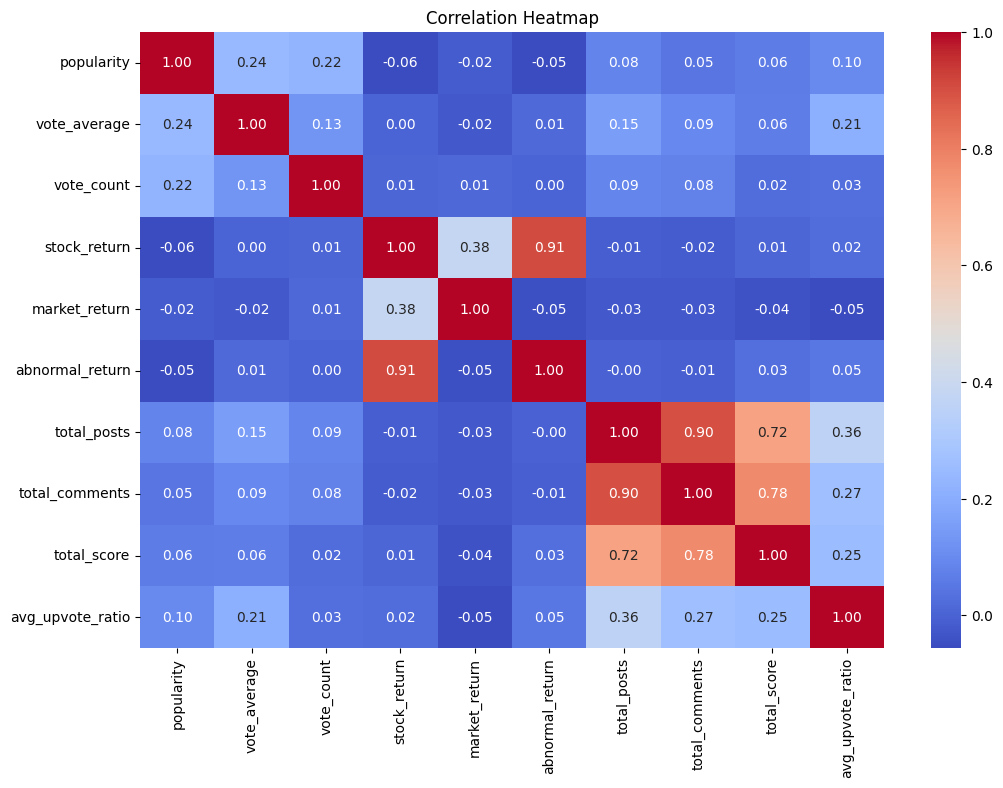

In [44]:
# Print the summary statistics for the merged dataset
merged_data_summary = merged_data.describe()
print("Summary Statistics for the Merged Dataset:")
display(merged_data_summary)

# Histograms for the numerical columns in the merged dataset
plt.figure(figsize=(16, 12))
plt.suptitle('Histograms of Continuous Variables', fontsize=20)

n_cols = 3
n_rows = 4

numerical_cols = ['popularity', 'vote_average', 'vote_count', 'stock_return', 
                  'market_return', 'abnormal_return', 'total_posts', 
                  'total_comments', 'total_score', 'avg_upvote_ratio']

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(merged_data[col], kde=True)
    plt.title(f'{col} Histogram')
    plt.axvline(merged_data[col].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {merged_data[col].mean():.2f}')
    plt.axvline(merged_data[col].median(), color='green', linestyle='dashed', linewidth=1, label=f'Median: {merged_data[col].median():.2f}')

plt.tight_layout()
plt.show()


# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(merged_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


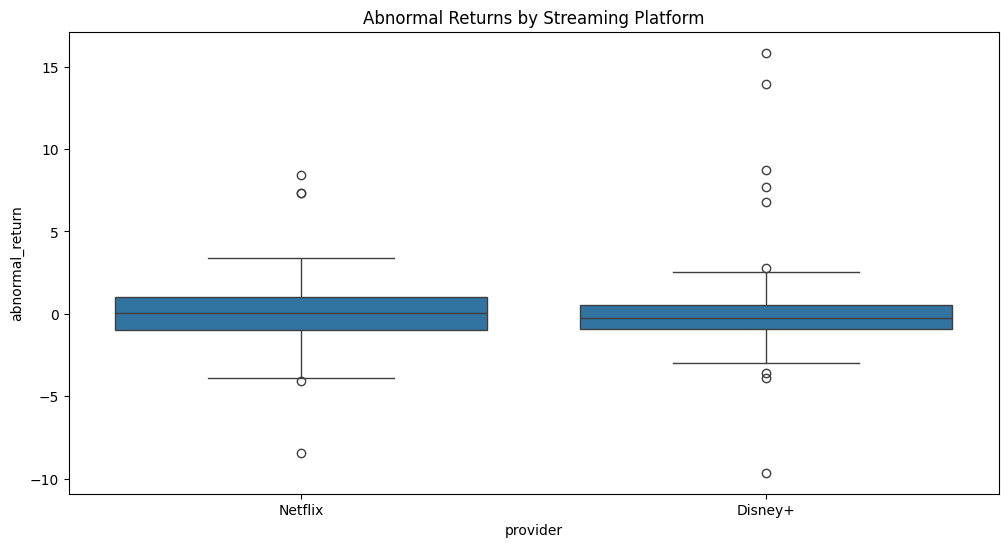

Text(0, 0.5, '3-Day Abnormal Return (%)')

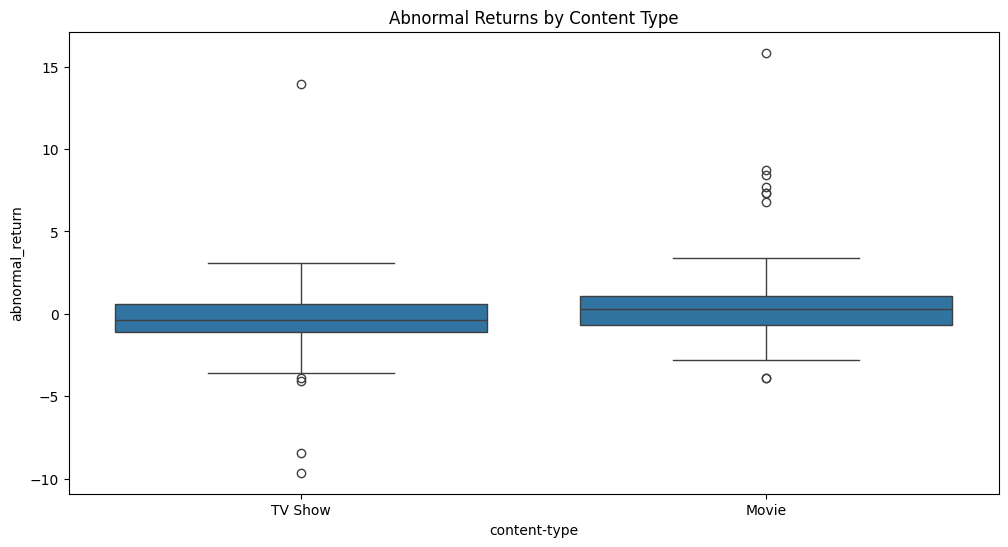

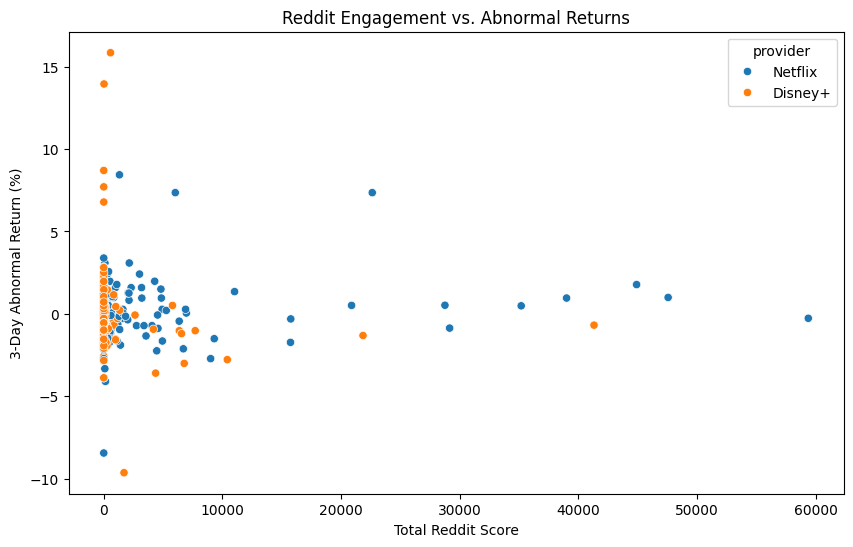

In [48]:
# Boxplot of Abnormal Returns by Streaming Platform
plt.figure(figsize=(12, 6))
sns.boxplot(x='provider', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by Streaming Platform')
plt.show()

# Boxplot of Abnormal Returns by Content Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='content-type', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by Content Type')

# Scatter plot of Reddit Engagement vs. Abnormal Returns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_score', y='abnormal_return', hue='provider', data=merged_data)
plt.title('Reddit Engagement vs. Abnormal Returns')
plt.xlabel('Total Reddit Score')
plt.ylabel('3-Day Abnormal Return (%)')

In [17]:
# To be deleted
print("Releases Data:")
display(releases_df.head())
print("Stock Data:")
display(stock_data.head())
print("Abnormal Returns Data:")
display(returns_df.head())
print("Reddit Engagement Data:")
display(engagement_df.head())

Releases Data:


,id,name,first_air_date,popularity,vote_average,vote_count,provider,provider_id,genres,content-type,release_date,ticker
0,207332,SAKAMOTO DAYS,2025-01-11,47.584,8.200,104,Netflix,8,"['Animation', 'Comedy', 'Action & Adventure']",TV Show,2025-01-11,NFLX
1,236994,Dragon Ball DAIMA,2024-10-11,10.502,8.132,403,Netflix,8,"['Animation', 'Action & Adventure', 'Comedy', ...",TV Show,2024-10-11,NFLX
2,207347,Blue Box,2024-10-03,16.200,8.500,17,Netflix,8,"['Animation', 'Comedy', 'Drama']",TV Show,2024-10-03,NFLX
3,275998,Who Saw the Peacock Dance in the Jungle?,2025-01-24,22.481,8.000,2,Netflix,8,"['Drama', 'Mystery']",TV Show,2025-01-24,NFLX
4,278421,Hell for You,2025-01-14,9.348,5.000,1,Netflix,8,['Drama'],TV Show,2025-01-14,NFLX


Stock Data:


,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Daily_Return
0,2024-01-25,DIS,94.007820,94.860001,94.940002,93.750000,93.919998,8661600,NaN
1,2024-01-26,DIS,94.503334,95.360001,95.529999,94.699997,95.000000,7812800,0.527099
2,2024-01-29,DIS,96.614197,97.489998,97.500000,95.000000,95.419998,13422200,2.233638
3,2024-01-30,DIS,96.069138,96.940002,97.540001,96.010002,96.519997,9139600,-0.564161
4,2024-01-31,DIS,95.187126,96.050003,97.570000,95.809998,96.419998,9592300,-0.918101


Abnormal Returns Data:


,id,name,first_air_date,popularity,vote_average,vote_count,provider,provider_id,genres,content-type,release_date,ticker,stock_return,market_return,abnormal_return
0,207332,SAKAMOTO DAYS,2025-01-11,47.584,8.200,104,Netflix,8,"['Animation', 'Comedy', 'Action & Adventure']",TV Show,2025-01-11,NFLX,-1.414982,0.114628,-1.529610
1,236994,Dragon Ball DAIMA,2024-10-11,10.502,8.132,403,Netflix,8,"['Animation', 'Action & Adventure', 'Comedy', ...",TV Show,2024-10-11,NFLX,-1.354471,0.770767,-2.125237
2,207347,Blue Box,2024-10-03,16.200,8.500,17,Netflix,8,"['Animation', 'Comedy', 'Drama']",TV Show,2024-10-03,NFLX,1.825131,0.897025,0.928106
3,275998,Who Saw the Peacock Dance in the Jungle?,2025-01-24,22.481,8.000,2,Netflix,8,"['Drama', 'Mystery']",TV Show,2025-01-24,NFLX,-0.583068,-1.458072,0.875004
4,278421,Hell for You,2025-01-14,9.348,5.000,1,Netflix,8,['Drama'],TV Show,2025-01-14,NFLX,3.585219,2.631394,0.953824


Reddit Engagement Data:


,total_posts,total_comments,total_score,avg_upvote_ratio,title,release_date
0,5,62,241,0.704000,SAKAMOTO DAYS,2025-01-11
1,3,152,987,0.743333,Dragon Ball DAIMA,2024-10-11
2,1,3,8,0.610000,Blue Box,2024-10-03
3,0,0,0,0.000000,Who Saw the Peacock Dance in the Jungle?,2025-01-24
4,0,0,0,0.000000,Hell for You,2025-01-14
